In [ ]:
%pip install pandas matplotlib seaborn scikit-learn

In [ ]:
# imports
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score
from sklearn.metrics import classification_report
from sklearn.metrics import confusion_matrix
from sklearn.metrics import roc_curve, roc_auc_score



### Task 1: Data Acquisition and Exploration


1. Download and load the dataset 


[Dataset Download link](https://archive.ics.uci.edu/dataset/17/breast+cancer+wisconsin+diagnostic)

https://archive.ics.uci.edu/dataset/17/breast+cancer+wisconsin+diagnostic


In [7]:
import pandas as pd

# Read wdbc.names file
with open("../Datasets/Lab 4/breast+cancer+wisconsin+diagnostic/wdbc.names", "r") as file:
    names_content = file.read()

print(names_content)

1. Title: Wisconsin Diagnostic Breast Cancer (WDBC)

2. Source Information

a) Creators: 

	Dr. William H. Wolberg, General Surgery Dept., University of
	Wisconsin,  Clinical Sciences Center, Madison, WI 53792
	wolberg@eagle.surgery.wisc.edu

	W. Nick Street, Computer Sciences Dept., University of
	Wisconsin, 1210 West Dayton St., Madison, WI 53706
	street@cs.wisc.edu  608-262-6619

	Olvi L. Mangasarian, Computer Sciences Dept., University of
	Wisconsin, 1210 West Dayton St., Madison, WI 53706
	olvi@cs.wisc.edu 

b) Donor: Nick Street

c) Date: November 1995

3. Past Usage:

first usage:

	W.N. Street, W.H. Wolberg and O.L. Mangasarian 
	Nuclear feature extraction for breast tumor diagnosis.
	IS&T/SPIE 1993 International Symposium on Electronic Imaging: Science
	and Technology, volume 1905, pages 861-870, San Jose, CA, 1993.

OR literature:

	O.L. Mangasarian, W.N. Street and W.H. Wolberg. 
	Breast cancer diagnosis and prognosis via linear programming. 
	Operations Research, 43(4), pag

In [6]:
# import pandas as pd

df = pd.read_csv('../Datasets/Lab 4/breast+cancer+wisconsin+diagnostic/wdbc.data', header=None)
df.head()

,0,1,2,3,4,5,6,7,8,9,...,22,23,24,25,26,27,28,29,30,31
0,842302,M,17.99,10.38,122.80,1001.0,0.11840,0.27760,0.3001,0.14710,...,25.38,17.33,184.60,2019.0,0.1622,0.6656,0.7119,0.2654,0.4601,0.11890
1,842517,M,20.57,17.77,132.90,1326.0,0.08474,0.07864,0.0869,0.07017,...,24.99,23.41,158.80,1956.0,0.1238,0.1866,0.2416,0.1860,0.2750,0.08902
2,84300903,M,19.69,21.25,130.00,1203.0,0.10960,0.15990,0.1974,0.12790,...,23.57,25.53,152.50,1709.0,0.1444,0.4245,0.4504,0.2430,0.3613,0.08758
3,84348301,M,11.42,20.38,77.58,386.1,0.14250,0.28390,0.2414,0.10520,...,14.91,26.50,98.87,567.7,0.2098,0.8663,0.6869,0.2575,0.6638,0.17300
4,84358402,M,20.29,14.34,135.10,1297.0,0.10030,0.13280,0.1980,0.10430,...,22.54,16.67,152.20,1575.0,0.1374,0.2050,0.4000,0.1625,0.2364,0.07678


In [ ]:
# import pandas as pd

# Column names according to wdbc.names
columns = [
    "ID", "Diagnosis",
    "radius_mean", "texture_mean", "perimeter_mean", "area_mean",
    "smoothness_mean", "compactness_mean", "concavity_mean",
    "concave_points_mean", "symmetry_mean", "fractal_dimension_mean",

    "radius_se", "texture_se", "perimeter_se", "area_se",
    "smoothness_se", "compactness_se", "concavity_se",
    "concave_points_se", "symmetry_se", "fractal_dimension_se",

    "radius_worst", "texture_worst", "perimeter_worst", "area_worst",
    "smoothness_worst", "compactness_worst", "concavity_worst",
    "concave_points_worst", "symmetry_worst", "fractal_dimension_worst"
]

# Load dataset
df = pd.read_csv("../Datasets/Lab 4/breast+cancer+wisconsin+diagnostic/wdbc.data", header=None, names=columns)

# Display first 5 rows
df.head()

,ID,Diagnosis,radius_mean,texture_mean,perimeter_mean,area_mean,smoothness_mean,compactness_mean,concavity_mean,concave_points_mean,...,radius_worst,texture_worst,perimeter_worst,area_worst,smoothness_worst,compactness_worst,concavity_worst,concave_points_worst,symmetry_worst,fractal_dimension_worst
0,842302,M,17.99,10.38,122.80,1001.0,0.11840,0.27760,0.3001,0.14710,...,25.38,17.33,184.60,2019.0,0.1622,0.6656,0.7119,0.2654,0.4601,0.11890
1,842517,M,20.57,17.77,132.90,1326.0,0.08474,0.07864,0.0869,0.07017,...,24.99,23.41,158.80,1956.0,0.1238,0.1866,0.2416,0.1860,0.2750,0.08902
2,84300903,M,19.69,21.25,130.00,1203.0,0.10960,0.15990,0.1974,0.12790,...,23.57,25.53,152.50,1709.0,0.1444,0.4245,0.4504,0.2430,0.3613,0.08758
3,84348301,M,11.42,20.38,77.58,386.1,0.14250,0.28390,0.2414,0.10520,...,14.91,26.50,98.87,567.7,0.2098,0.8663,0.6869,0.2575,0.6638,0.17300
4,84358402,M,20.29,14.34,135.10,1297.0,0.10030,0.13280,0.1980,0.10430,...,22.54,16.67,152.20,1575.0,0.1374,0.2050,0.4000,0.1625,0.2364,0.07678


2. Compute summary statistics (mean, median, standard deviation, etc.) for all features.


In [9]:
# Summary statistics for numerical features
df.describe()

,ID,radius_mean,texture_mean,perimeter_mean,area_mean,smoothness_mean,compactness_mean,concavity_mean,concave_points_mean,symmetry_mean,...,radius_worst,texture_worst,perimeter_worst,area_worst,smoothness_worst,compactness_worst,concavity_worst,concave_points_worst,symmetry_worst,fractal_dimension_worst
count,5.690000e+02,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000,...,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000
mean,3.037183e+07,14.127292,19.289649,91.969033,654.889104,0.096360,0.104341,0.088799,0.048919,0.181162,...,16.269190,25.677223,107.261213,880.583128,0.132369,0.254265,0.272188,0.114606,0.290076,0.083946
std,1.250206e+08,3.524049,4.301036,24.298981,351.914129,0.014064,0.052813,0.079720,0.038803,0.027414,...,4.833242,6.146258,33.602542,569.356993,0.022832,0.157336,0.208624,0.065732,0.061867,0.018061
min,8.670000e+03,6.981000,9.710000,43.790000,143.500000,0.052630,0.019380,0.000000,0.000000,0.106000,...,7.930000,12.020000,50.410000,185.200000,0.071170,0.027290,0.000000,0.000000,0.156500,0.055040
25%,8.692180e+05,11.700000,16.170000,75.170000,420.300000,0.086370,0.064920,0.029560,0.020310,0.161900,...,13.010000,21.080000,84.110000,515.300000,0.116600,0.147200,0.114500,0.064930,0.250400,0.071460
50%,9.060240e+05,13.370000,18.840000,86.240000,551.100000,0.095870,0.092630,0.061540,0.033500,0.179200,...,14.970000,25.410000,97.660000,686.500000,0.131300,0.211900,0.226700,0.099930,0.282200,0.080040
75%,8.813129e+06,15.780000,21.800000,104.100000,782.700000,0.105300,0.130400,0.130700,0.074000,0.195700,...,18.790000,29.720000,125.400000,1084.000000,0.146000,0.339100,0.382900,0.161400,0.317900,0.092080
max,9.113205e+08,28.110000,39.280000,188.500000,2501.000000,0.163400,0.345400,0.426800,0.201200,0.304000,...,36.040000,49.540000,251.200000,4254.000000,0.222600,1.058000,1.252000,0.291000,0.663800,0.207500


In [10]:
summary = pd.DataFrame({
    "Mean": df.mean(numeric_only=True),
    "Median": df.median(numeric_only=True),
    "Standard Deviation": df.std(numeric_only=True)
})

summary

,Mean,Median,Standard Deviation
ID,3.037183e+07,906024.000000,1.250206e+08
radius_mean,1.412729e+01,13.370000,3.524049e+00
texture_mean,1.928965e+01,18.840000,4.301036e+00
perimeter_mean,9.196903e+01,86.240000,2.429898e+01
area_mean,6.548891e+02,551.100000,3.519141e+02
smoothness_mean,9.636028e-02,0.095870,1.406413e-02
compactness_mean,1.043410e-01,0.092630,5.281276e-02
concavity_mean,8.879932e-02,0.061540,7.971981e-02
concave_points_mean,4.891915e-02,0.033500,3.880284e-02
symmetry_mean,1.811619e-01,0.179200,2.741428e-02


3. Check for missing values, duplicates, or outliers. Handle them 


In [11]:
# Check missing values in each column
missing_values = df.isnull().sum()

print("Missing values in each column:")
print(missing_values)

print("\nTotal missing values:", missing_values.sum())

Missing values in each column:
ID                         0
Diagnosis                  0
radius_mean                0
texture_mean               0
perimeter_mean             0
area_mean                  0
smoothness_mean            0
compactness_mean           0
concavity_mean             0
concave_points_mean        0
symmetry_mean              0
fractal_dimension_mean     0
radius_se                  0
texture_se                 0
perimeter_se               0
area_se                    0
smoothness_se              0
compactness_se             0
concavity_se               0
concave_points_se          0
symmetry_se                0
fractal_dimension_se       0
radius_worst               0
texture_worst              0
perimeter_worst            0
area_worst                 0
smoothness_worst           0
compactness_worst          0
concavity_worst            0
concave_points_worst       0
symmetry_worst             0
fractal_dimension_worst    0
dtype: int64

Total missing values: 0


In [12]:
# Check duplicate rows
duplicates = df.duplicated().sum()

print("Number of duplicate rows:", duplicates)

Number of duplicate rows: 0


In [13]:
# Select the 30 numerical features
features = df.columns[2:]

# Calculate Q1, Q3 and IQR
Q1 = df[features].quantile(0.25)
Q3 = df[features].quantile(0.75)
IQR = Q3 - Q1

# Identify outliers
outliers = ((df[features] < (Q1 - 1.5 * IQR)) |
            (df[features] > (Q3 + 1.5 * IQR)))

# Count outliers in each feature
outlier_counts = outliers.sum()

print("Number of outliers in each feature:")
print(outlier_counts)

Number of outliers in each feature:
radius_mean                14
texture_mean                7
perimeter_mean             13
area_mean                  25
smoothness_mean             6
compactness_mean           16
concavity_mean             18
concave_points_mean        10
symmetry_mean              15
fractal_dimension_mean     15
radius_se                  38
texture_se                 20
perimeter_se               38
area_se                    65
smoothness_se              30
compactness_se             28
concavity_se               22
concave_points_se          19
symmetry_se                27
fractal_dimension_se       28
radius_worst               17
texture_worst               5
perimeter_worst            15
area_worst                 35
smoothness_worst            7
compactness_worst          16
concavity_worst            12
concave_points_worst        0
symmetry_worst             23
fractal_dimension_worst    24
dtype: int64


In [14]:
# Handle outliers using IQR capping
lower_bound = Q1 - 1.5 * IQR
upper_bound = Q3 + 1.5 * IQR

df[features] = df[features].clip(
    lower=lower_bound,
    upper=upper_bound,
    axis=1
)

print("Outliers handled using IQR capping.")

Outliers handled using IQR capping.


In [15]:
print("Final dataset shape:", df.shape)
print("Total missing values:", df.isnull().sum().sum())
print("Total duplicate rows:", df.duplicated().sum())

Final dataset shape: (569, 32)
Total missing values: 0
Total duplicate rows: 0


4. Visualize the data: Create histograms or box plots for key features, a correlation
heatmap, and class distribution.

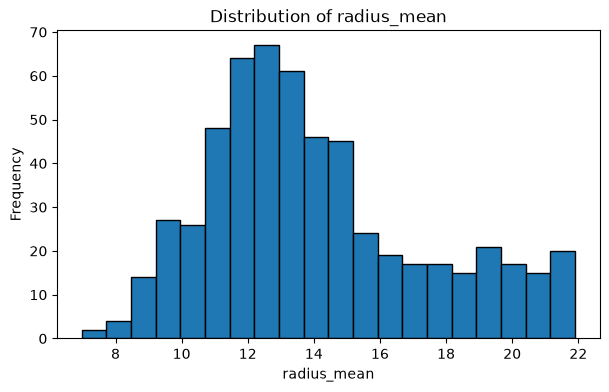

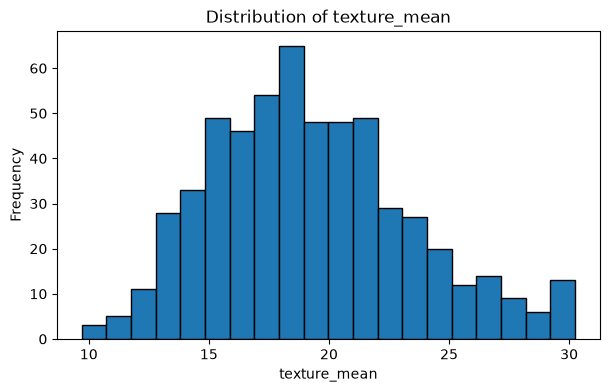

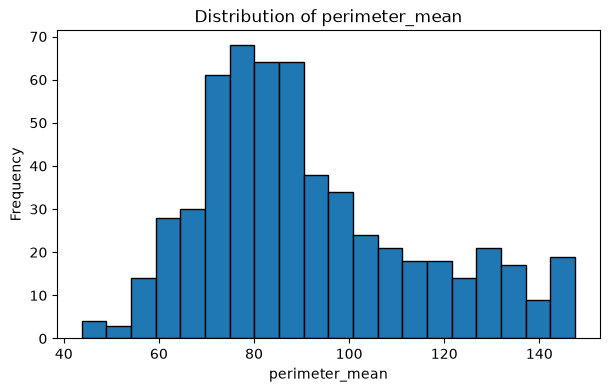

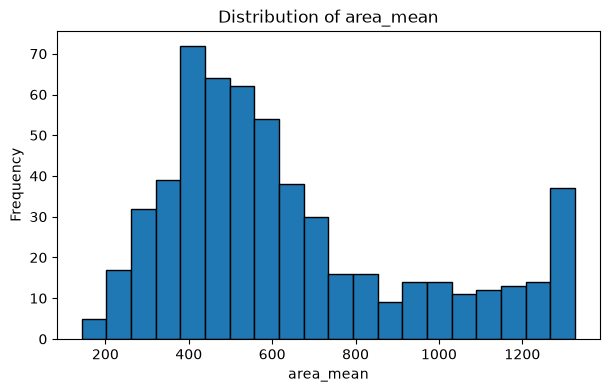

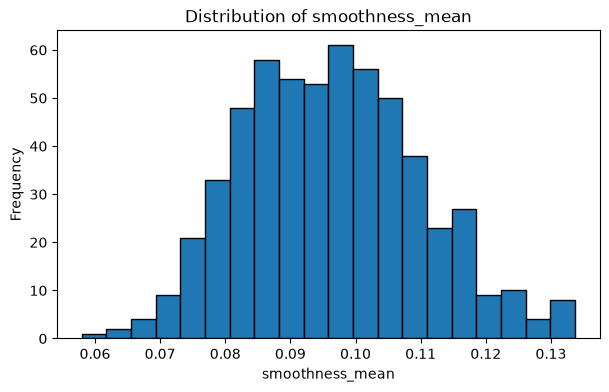

In [ ]:
# import matplotlib.pyplot as plt

# Key features
key_features = [
    "radius_mean",
    "texture_mean",
    "perimeter_mean",
    "area_mean",
    "smoothness_mean"
]

# Create histograms
for feature in key_features:
    plt.figure(figsize=(7, 4))
    plt.hist(df[feature], bins=20, edgecolor="black")
    plt.title(f"Distribution of {feature}")
    plt.xlabel(feature)
    plt.ylabel("Frequency")
    plt.show()

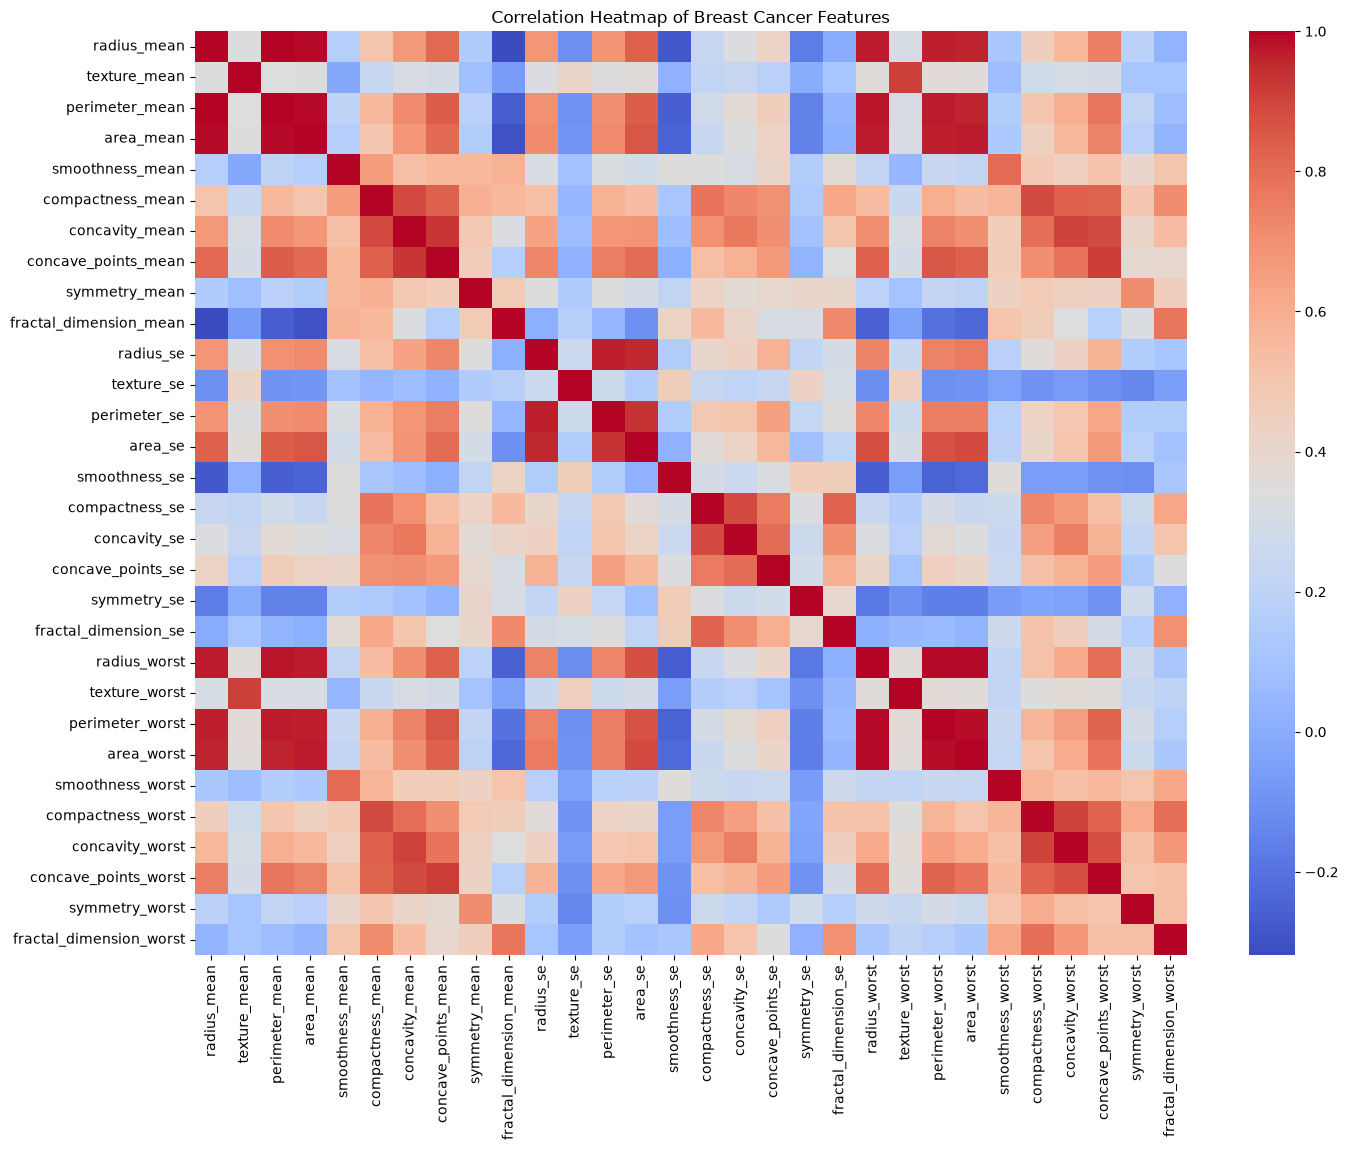

In [ ]:
# import seaborn as sns
# import matplotlib.pyplot as plt

# Select numerical features
numerical_features = df.iloc[:, 2:]

# Calculate correlation matrix
correlation_matrix = numerical_features.corr()

# Plot heatmap
plt.figure(figsize=(16, 12))
sns.heatmap(
    correlation_matrix,
    cmap="coolwarm",
    annot=False
)

plt.title("Correlation Heatmap of Breast Cancer Features")
plt.show()

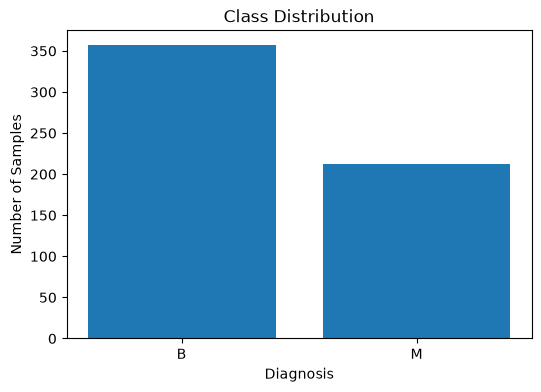

In [19]:
# Count the classes
class_counts = df["Diagnosis"].value_counts()

# Plot class distribution
plt.figure(figsize=(6, 4))
plt.bar(class_counts.index, class_counts.values)

plt.title("Class Distribution")
plt.xlabel("Diagnosis")
plt.ylabel("Number of Samples")

plt.show()

5. Discuss any imbalances in the class distribution and potential implications for model
training.

This dataset has moderate class imbalance. This imbalance may cause the logistic regression model to favor the majority class and may reduce its ability to correctly identify malignant cases.

### Task 2: Data PreprocessingTask 2: Data Preprocessing

• Encode the target variable (Outcome) as binary

In [20]:
# Encode Diagnosis as binary
df["Diagnosis"] = df["Diagnosis"].map({"B": 0, "M": 1})

# Check the encoded values
print(df["Diagnosis"].value_counts())

Diagnosis
0    357
1    212
Name: count, dtype: int64


• Split the data into training and testing sets (e.g., 80/20 split) using stratified sampling
to maintain class balance. 

In [23]:
# from sklearn.model_selection import train_test_split

# Features and target
X = df.drop(columns=["ID", "Diagnosis"])
y = df["Diagnosis"]

# Split data into training and testing sets (80/20)
# Stratify ensures the same class proportion in both sets
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=42,
    stratify=y
)

# Check the shapes
print("Training set shape:", X_train.shape)
print("Testing set shape:", X_test.shape)

Training set shape: (455, 30)
Testing set shape: (114, 30)


This is done using stratify to handle class imbalance and now we are check that class imbalance is handeled successfully or not.

In [25]:
print("Training set class percentage:")
print(y_train.value_counts(normalize=True) * 100)

print("\nTesting set class percentage:")
print(y_test.value_counts(normalize=True) * 100)

Training set class percentage:
Diagnosis
0    62.637363
1    37.362637
Name: proportion, dtype: float64

Testing set class percentage:
Diagnosis
0    63.157895
1    36.842105
Name: proportion, dtype: float64


• Standardize the features to ensure they are on the same scale, as logistic regression is
sensitive to feature scales. 

In [ ]:
# from sklearn.preprocessing import StandardScaler

# Create StandardScaler
scaler = StandardScaler()

# Fit on training data and transform training data
X_train_scaled = scaler.fit_transform(X_train)

# Transform test data using the same scaler
X_test_scaled = scaler.transform(X_test)

# Check the shapes
print("Scaled training set shape:", X_train_scaled.shape)
print("Scaled testing set shape:", X_test_scaled.shape)

Scaled training set shape: (455, 30)
Scaled testing set shape: (114, 30)


### Task 3: Model Training and Basic Evaluation

• Train a logistic regression model

In [ ]:
# from sklearn.linear_model import LogisticRegression

# Create Logistic Regression model
logistic_model = LogisticRegression(random_state=42)

# Train the model
logistic_model.fit(X_train_scaled, y_train)

print("Logistic Regression model trained successfully.")

Logistic Regression model trained successfully.


• Evaluate the model on the test set using the following metrics:

• Accuracy

• Precision, Recall, and F1-score (report for both classes)

• Confusion matrix (visualize it)

• ROC curve and AUC score


In [ ]:
# from sklearn.metrics import accuracy_score

y_pred = logistic_model.predict(X_test_scaled)

accuracy = accuracy_score(y_test, y_pred)

print("Accuracy:", accuracy)

Accuracy: 0.9649122807017544


In [ ]:
# from sklearn.metrics import classification_report

print(classification_report(
    y_test,
    y_pred,
    target_names=["Benign", "Malignant"]
))

              precision    recall  f1-score   support

      Benign       0.96      0.99      0.97        72
   Malignant       0.97      0.93      0.95        42

    accuracy                           0.96       114
   macro avg       0.97      0.96      0.96       114
weighted avg       0.97      0.96      0.96       114



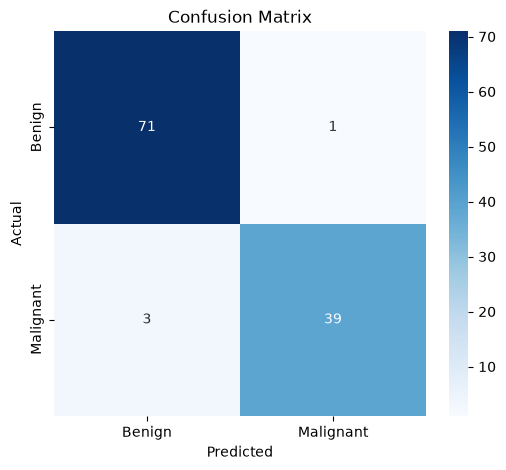

In [ ]:
# from sklearn.metrics import confusion_matrix
# import seaborn as sns
# import matplotlib.pyplot as plt

cm = confusion_matrix(y_test, y_pred)

plt.figure(figsize=(6, 5))
sns.heatmap(
    cm,
    annot=True,
    fmt="d",
    cmap="Blues",
    xticklabels=["Benign", "Malignant"],
    yticklabels=["Benign", "Malignant"]
)

plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Confusion Matrix")
plt.show()

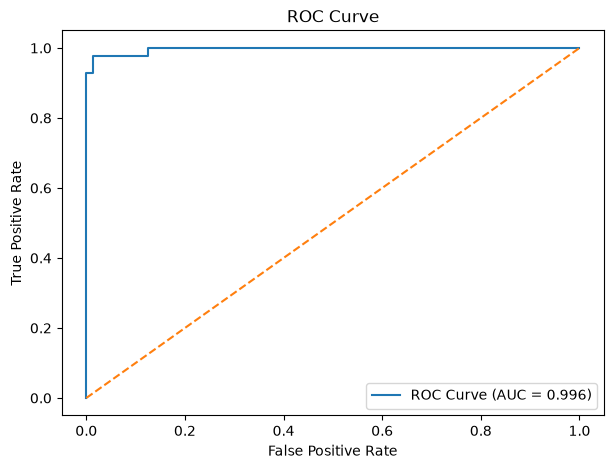

AUC Score: 0.9963624338624338


In [ ]:
# from sklearn.metrics import roc_curve, roc_auc_score
# import matplotlib.pyplot as plt

y_prob = logistic_model.predict_proba(X_test_scaled)[:, 1]

fpr, tpr, thresholds = roc_curve(y_test, y_prob)

auc_score = roc_auc_score(y_test, y_prob)

plt.figure(figsize=(7, 5))
plt.plot(fpr, tpr, label=f"ROC Curve (AUC = {auc_score:.3f})")
plt.plot([0, 1], [0, 1], linestyle="--")

plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve")
plt.legend()
plt.show()

print("AUC Score:", auc_score)